# E-ComShield — Análise Exploratória de Dados (EDA)

Esta EDA utiliza o dataset TalkEx Augmented PT-BR já inspecionado e tratado no notebook `01_data_cleaning.ipynb`. A fonte desta análise é `data/processed/talkex_clean.csv`.

Na etapa anterior, strings vazias de `sector` e `sentiment` nos registros sintéticos foram convertidas para valores ausentes. Nenhuma conversa foi removida.

## 1. Carregamento e validação

Os caminhos são identificados a partir da raiz do projeto, sem depender de caminhos absolutos da máquina.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', palette='deep')

def find_project_root(start_path: Path) -> Path:
    for candidate in (start_path, *start_path.parents):
        if (candidate / 'pyproject.toml').exists():
            return candidate
    raise FileNotFoundError('pyproject.toml não foi encontrado.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'talkex_clean.csv'

df = pd.read_csv(DATA_PATH)
print(f'Dataset carregado: {DATA_PATH.relative_to(PROJECT_ROOT)}')
print(f'Shape: {df.shape}')

Dataset carregado: data/processed/talkex_clean.csv
Shape: (2120, 7)


In [2]:
print('Tipos de dados:')
display(df.dtypes.rename('dtype').to_frame())
print('\nResumo descritivo:')
display(df.describe(include='all').T)
print('\nValores ausentes:')
display(df.isna().sum().rename('valores_ausentes').to_frame())
print(f'\nDuplicatas exatas: {df.duplicated().sum():,}')

Tipos de dados:


,dtype
conv_id,object
text,object
intent,object
sector,object
sentiment,object
turns,int64
_synthetic,bool



Resumo descritivo:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
conv_id,2120,2120,conv_00384,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
text,2120,2120,"[customer] Oi, vc pode me ajudar? Quero contra...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
intent,2120,8,compra,265,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sector,676,8,ecommerce,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sentiment,676,3,neutral,231,NaN,NaN,NaN,NaN,NaN,NaN,NaN
turns,2120.0,NaN,NaN,NaN,7.842925,0.962902,5.0,7.0,8.0,8.0,13.0
_synthetic,2120,2,True,1444,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Valores ausentes:


,valores_ausentes
conv_id,0
text,0
intent,0
sector,1444
sentiment,1444
turns,0
_synthetic,0



Duplicatas exatas: 0


## 2. Variáveis derivadas para análise

`text_length` representa o número de caracteres de cada conversa e `word_count` uma contagem aproximada de palavras. A coluna original `text` é preservada.

In [3]:
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

display(df[['text_length', 'word_count', 'turns']].describe())

,text_length,word_count,turns
count,2120.000000,2120.000000,2120.000000
mean,848.339151,145.919811,7.842925
std,233.745962,43.605423,0.962902
min,403.000000,66.000000,5.000000
25%,674.000000,113.000000,7.000000
50%,794.500000,136.000000,8.000000
75%,974.250000,171.000000,8.000000
max,1866.000000,329.000000,13.000000


## 3. Distribuição das intenções

A tabela e o gráfico mostram a quantidade e o percentual de conversas por intenção.

,intent,quantidade,percentual
0,cancelamento,265,12.5
1,compra,265,12.5
2,duvida_produto,265,12.5
3,duvida_servico,265,12.5
4,elogio,265,12.5
5,reclamacao,265,12.5
6,saudacao,265,12.5
7,suporte_tecnico,265,12.5


Quantidade de intenções: 8


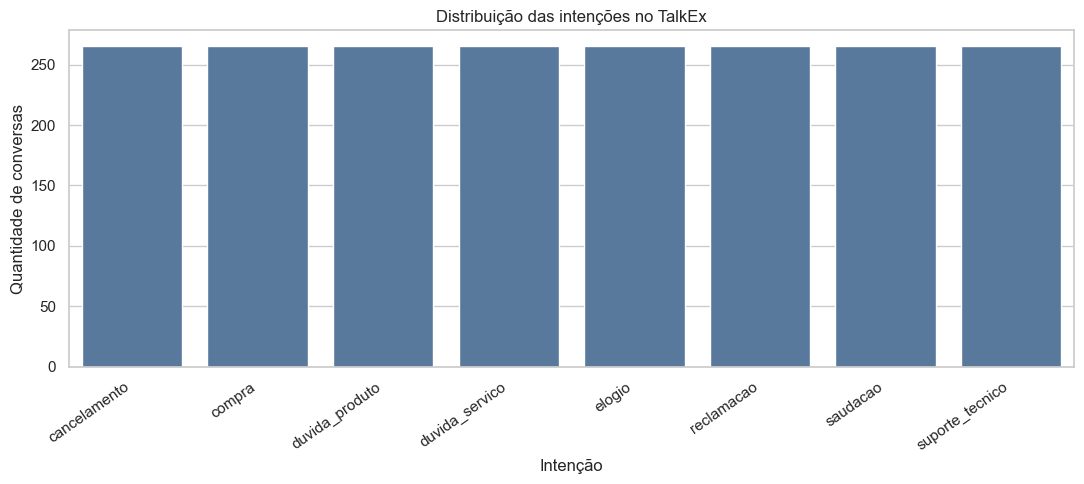

In [4]:
intent_summary = df['intent'].value_counts().sort_index().rename_axis('intent').reset_index(name='quantidade')
intent_summary['percentual'] = (intent_summary['quantidade'] / len(df) * 100).round(2)
display(intent_summary)
print(f'Quantidade de intenções: {df["intent"].nunique()}')

plt.figure(figsize=(11, 5))
sns.barplot(data=intent_summary, x='intent', y='quantidade', color='#4C78A8')
plt.title('Distribuição das intenções no TalkEx')
plt.xlabel('Intenção')
plt.ylabel('Quantidade de conversas')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

**Interpretação.** Há 8 intenções e cada uma possui 265 conversas (12,5% do total). A distribuição perfeitamente balanceada é uma característica da composição do TalkEx, e não um problema de qualidade para esta análise exploratória.

## 4. Distribuição do tamanho das conversas

O histograma permite observar como os comprimentos das conversas se distribuem no conjunto completo.

,text_length
mean,848.339151
min,403.000000
25%,674.000000
50%,794.500000
75%,974.250000
max,1866.000000


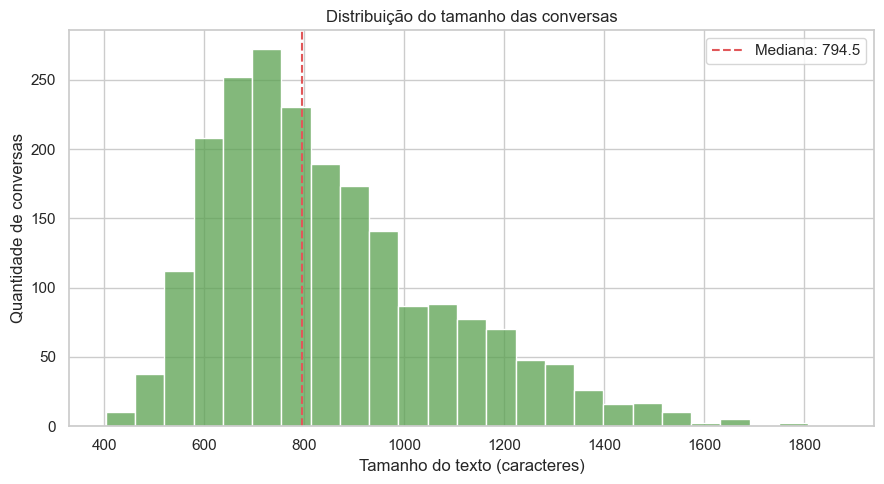

In [5]:
text_length_summary = df['text_length'].describe()[['mean', 'min', '25%', '50%', '75%', 'max']].rename('text_length').to_frame()
display(text_length_summary)

plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='text_length', bins=25, color='#59A14F', edgecolor='white')
plt.axvline(df['text_length'].median(), color='#E15759', linestyle='--', label=f"Mediana: {df['text_length'].median():.1f}")
plt.title('Distribuição do tamanho das conversas')
plt.xlabel('Tamanho do texto (caracteres)')
plt.ylabel('Quantidade de conversas')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretação.** O tamanho médio é de 848,3 caracteres e a mediana é de 794,5. Metade das conversas está entre 674,0 e 974,25 caracteres; os valores variam de 403 a 1.866. O histograma concentra a maior parte dos registros nessa faixa central, enquanto a média acima da mediana reflete a presença de conversas mais longas.

## 5. Tamanho das conversas por intenção

A comparação por intenção verifica se os comprimentos observados são semelhantes entre as classes.

,count,mean,median,min,max
intent,,,,,
duvida_servico,265,956.47,904.0,533,1689
duvida_produto,265,940.48,895.0,536,1866
suporte_tecnico,265,897.36,866.0,482,1529
compra,265,882.62,839.0,491,1638
reclamacao,265,826.93,766.0,526,1638
elogio,265,780.63,689.0,450,1732
cancelamento,265,756.26,693.0,403,1566
saudacao,265,745.96,690.0,452,1431


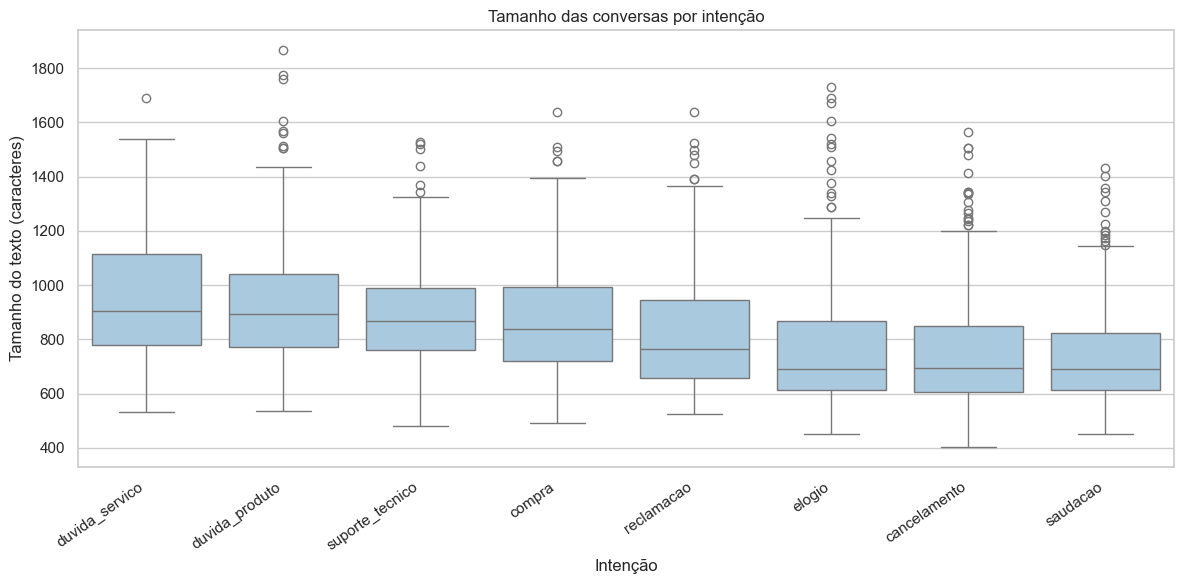

In [6]:
intent_length_summary = (
    df.groupby('intent')['text_length']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .sort_values('mean', ascending=False)
    .round(2)
)
display(intent_length_summary)

intent_order = intent_length_summary.index.tolist()
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='intent', y='text_length', order=intent_order, color='#A0CBE8')
plt.title('Tamanho das conversas por intenção')
plt.xlabel('Intenção')
plt.ylabel('Tamanho do texto (caracteres)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

**Interpretação.** `duvida_servico` (média 956,5 caracteres) e `duvida_produto` (940,5) apresentam as maiores médias. `saudacao` (746,0) e `cancelamento` (756,3) apresentam as menores. Os boxplots mostram sobreposição entre as distribuições, mas também diferenças nas posições centrais entre algumas intenções.

## 6. Análise de sentimento

`sentiment` está disponível apenas para as 676 conversas originais. Os 1.444 valores ausentes dos registros sintéticos não são tratados como uma categoria de sentimento.

,sentiment,quantidade,percentual
0,neutral,231,34.17
1,negative,223,32.99
2,positive,222,32.84


sentiment,negative,neutral,positive
intent,,,
cancelamento,36.71,32.91,30.38
compra,36.47,31.76,31.76
duvida_produto,38.75,32.50,28.75
duvida_servico,31.03,37.93,31.03
elogio,29.41,34.12,36.47
reclamacao,28.57,35.71,35.71
saudacao,32.95,34.09,32.95
suporte_tecnico,30.68,34.09,35.23


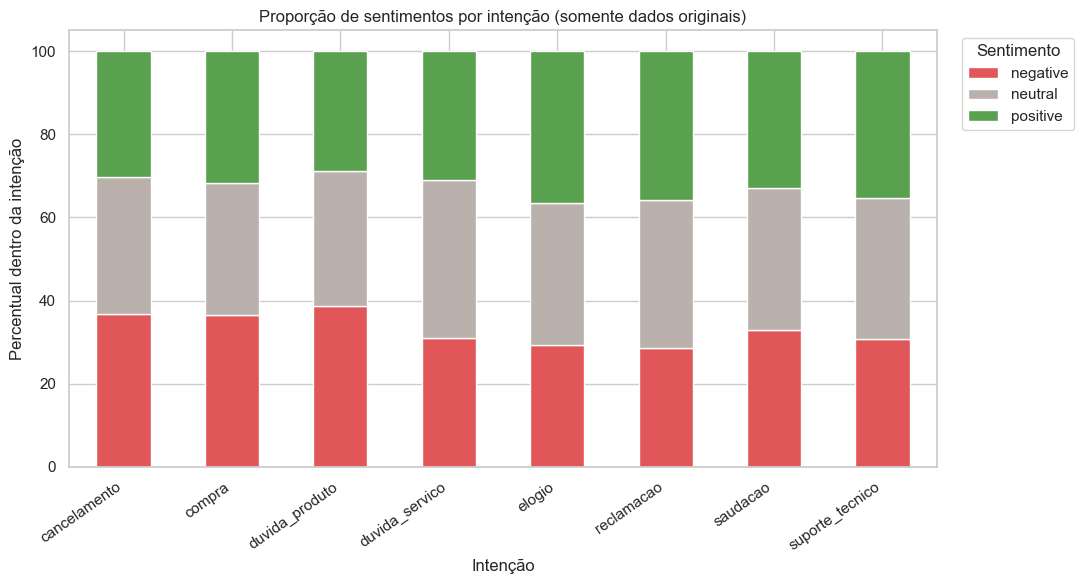

In [7]:
sentiment_df = df[df['sentiment'].notna()].copy()
sentiment_summary = sentiment_df['sentiment'].value_counts().rename_axis('sentiment').reset_index(name='quantidade')
sentiment_summary['percentual'] = (sentiment_summary['quantidade'] / len(sentiment_df) * 100).round(2)
display(sentiment_summary)

sentiment_by_intent = pd.crosstab(sentiment_df['intent'], sentiment_df['sentiment'], normalize='index').mul(100).round(2)
display(sentiment_by_intent)

sentiment_by_intent.plot(kind='bar', stacked=True, figsize=(11, 6), color=['#E15759', '#BAB0AC', '#59A14F'])
plt.title('Proporção de sentimentos por intenção (somente dados originais)')
plt.xlabel('Intenção')
plt.ylabel('Percentual dentro da intenção')
plt.legend(title='Sentimento', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

**Interpretação.** Nos dados com sentimento disponível, há 231 registros neutros (34,17%), 223 negativos (32,99%) e 222 positivos (32,84%). As proporções por intenção variam, mas devem ser interpretadas apenas como comportamento das conversas originais.

## 7. Original versus sintético

A origem das conversas é analisada para comparar características estruturais, sem pressupor que uma origem tenha qualidade superior à outra.

,origem,quantidade,percentual
0,Sintético,1444,68.11
1,Original,676,31.89


text_length         word_count        turns       
                 mean  median       mean median  mean median
origem                                                      
Original      1091.57  1089.0     192.83  192.0  7.82    8.0
Sintético      734.47   723.0     123.96  122.0  7.85    8.0

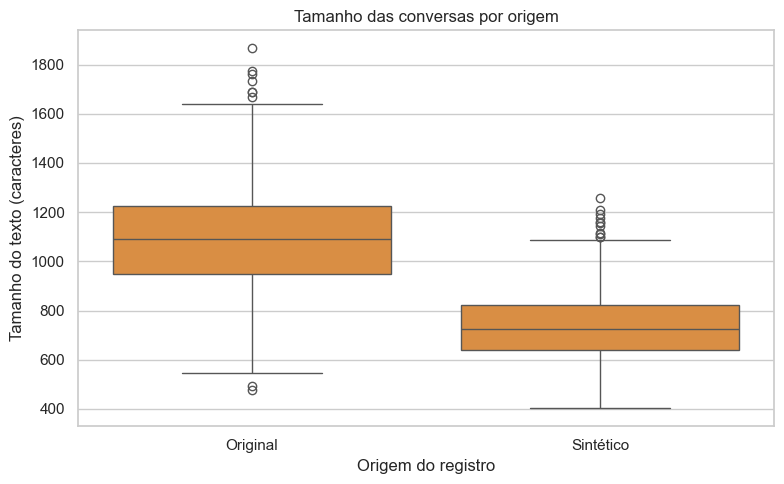

In [8]:
df['origem'] = df['_synthetic'].map({False: 'Original', True: 'Sintético'})
origin_summary = df['origem'].value_counts().rename_axis('origem').reset_index(name='quantidade')
origin_summary['percentual'] = (origin_summary['quantidade'] / len(df) * 100).round(2)
display(origin_summary)

origin_metrics = df.groupby('origem')[['text_length', 'word_count', 'turns']].agg(['mean', 'median']).round(2)
display(origin_metrics)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='origem', y='text_length', order=['Original', 'Sintético'], color='#F28E2B')
plt.title('Tamanho das conversas por origem')
plt.xlabel('Origem do registro')
plt.ylabel('Tamanho do texto (caracteres)')
plt.tight_layout()
plt.show()

**Interpretação.** Há 676 conversas originais (31,89%) e 1.444 sintéticas (68,11%). As originais têm texto médio de 1.091,6 caracteres, 192,8 palavras e 7,82 turnos; as sintéticas têm 734,5 caracteres, 124,0 palavras e 7,85 turnos. Assim, observou-se diferença no tamanho textual, enquanto a quantidade típica de turnos é semelhante (mediana 8 em ambas).

# Hipóteses investigadas

## H1 — O tamanho das conversas varia entre diferentes intenções

A tabela e o boxplot por intenção mostram médias entre 746,0 (`saudacao`) e 956,5 (`duvida_servico`) caracteres. Os dados apresentam evidência exploratória compatível com a hipótese: há variação de tamanho entre intenções, mesmo com sobreposição entre suas distribuições.

## H2 — Intenções relacionadas a reclamação apresentam maior concentração de sentimento negativo

A análise foi feita somente nas 676 conversas com `sentiment` disponível. Em `reclamacao`, 28,57% dos registros são negativos; nas demais intenções em conjunto, a proporção negativa é 33,61%. Portanto, os dados disponíveis não apresentam evidência exploratória compatível com a hipótese de maior concentração de sentimento negativo em `reclamacao`.

## H3 — Conversas originais e sintéticas apresentam diferenças em características estruturais

A comparação mostra textos originais mais longos, em média e mediana, tanto em caracteres quanto em palavras. Já `turns` apresenta médias próximas (7,82 nas originais e 7,85 nas sintéticas) e mediana 8 em ambas. Os dados sugerem diferença estrutural no tamanho textual, mas não uma diferença relevante na quantidade típica de turnos.

# Principais conclusões da EDA

- As 8 intenções possuem a mesma quantidade de registros, refletindo o balanceamento planejado do dataset.
- As conversas têm mediana de 794,5 caracteres e 136 palavras, com variação compatível com diálogos multi-turno.
- As intenções `duvida_servico` e `duvida_produto` apresentam conversas mais longas em média; `saudacao` e `cancelamento`, mais curtas.
- Nos registros originais com sentimento disponível, a distribuição geral entre neutro, negativo e positivo é próxima; `reclamacao` não apresentou a maior proporção negativa.
- Os registros originais são textualmente mais longos que os sintéticos, mas ambos têm mediana de 8 turnos.
- H1 foi apoiada de forma exploratória; H2 não foi apoiada pelos dados disponíveis; H3 foi apoiada para tamanho textual, mas não para quantidade típica de turnos.

## Limitações

- O dataset é parcialmente sintético.
- `sector` e `sentiment` não estão disponíveis para registros sintéticos.
- As intenções são relativamente amplas.
- Esta EDA descreve associações observadas e não implica causalidade.
- O dataset pode não cobrir todas as intenções futuras específicas do E-ComShield.